# Step 5 — Modality Ablation Study (TensorFlow/Keras)

This notebook measures how much each modality contributes to valve durability prediction.

## Models compared

1. **Valve only**
2. **Physiology only**
3. **Medications only**
4. **Valve + Physiology**
5. **Full multimodal** = Valve + Physiology + Medications

All models use:

- the same patient-level train/validation/test split,
- the same preprocessing fitted on train only,
- the same discrete-time survival loss,
- early stopping,
- the same evaluation metrics.

## Main metrics

- Harrell C-index
- Brier @5y
- Integrated Brier Score
- Time-dependent AUC @5y
- Test survival NLL

The goal is not to maximize performance here, but to understand **which branches actually carry predictive signal**.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_CSV = Path("synthetic_generator_outputs_v2/synthetic_multimodal_patient_year_v2_MODEL_READY.csv")
SPEC_JSON = Path("synthetic_generator_outputs_v2/encoder_input_spec_v2.json")

df = pd.read_csv(DATA_CSV)
with open(SPEC_JSON, "r", encoding="utf-8") as f:
    spec = json.load(f)

PATIENT_COL = spec["patient_id_column"]
TIME_COL = spec["time_column"]

STATIC_FEATURES = [c for c in spec["static_features"] if c != "valve_position"]
PHYS_FEATURES = spec["physiology_features"]
MED_FEATURES = spec["medication_features"]
NOTE_FEATURES = spec.get("note_derived_features_v1_optional", [])

print("TensorFlow:", tf.__version__)
print("Dataset:", df.shape)
print("Patients:", df[PATIENT_COL].nunique())


TensorFlow: 2.10.0
Dataset: (7169, 67)
Patients: 1000


## 1. Same patient split as before

In [2]:
patient_table = (
    df[[PATIENT_COL, "event", "duration_months"]]
    .drop_duplicates(PATIENT_COL)
    .reset_index(drop=True)
)

g1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
tr_idx, tmp_idx = next(g1.split(patient_table, groups=patient_table[PATIENT_COL]))

train_patients = patient_table.iloc[tr_idx][PATIENT_COL].tolist()
tmp = patient_table.iloc[tmp_idx].reset_index(drop=True)

g2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=SEED + 1)
va_idx, te_idx = next(g2.split(tmp, groups=tmp[PATIENT_COL]))

val_patients = tmp.iloc[va_idx][PATIENT_COL].tolist()
test_patients = tmp.iloc[te_idx][PATIENT_COL].tolist()

print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))


Train: 700
Validation: 150
Test: 150


## 2. Fit preprocessing on training patients only

In [3]:
train_df = df[df[PATIENT_COL].isin(train_patients)].copy()

STATIC_NUMERIC = [
    c for c in STATIC_FEATURES
    if pd.api.types.is_numeric_dtype(train_df[c])
]

STATIC_CATEGORICAL = [
    c for c in STATIC_FEATURES
    if c not in STATIC_NUMERIC
]

static_rows = (
    train_df
    .sort_values([PATIENT_COL, TIME_COL])
    .groupby(PATIENT_COL)
    .first()
    .reset_index()
)

static_scaler = StandardScaler().fit(
    static_rows[STATIC_NUMERIC].astype(float)
)

try:
    static_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    static_ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

static_ohe.fit(
    static_rows[STATIC_CATEGORICAL].astype(str)
)

phys_train = train_df[PHYS_FEATURES].apply(pd.to_numeric, errors="coerce")
phys_mean = phys_train.mean().fillna(0.0)
phys_std = phys_train.std().replace(0, 1.0).fillna(1.0)

TIME_SCALE = max(float(train_df[TIME_COL].max()), 1.0)


## 3. Build patient arrays

In [4]:
def transform_static(pdf):
    first = pdf.sort_values(TIME_COL).iloc[0]

    num = first[STATIC_NUMERIC].astype(float).to_numpy().reshape(1, -1)
    num = static_scaler.transform(num)

    cat = first[STATIC_CATEGORICAL].astype(str).to_numpy().reshape(1, -1)
    cat = static_ohe.transform(cat)

    return np.concatenate([num, cat], axis=1).astype(np.float32).squeeze(0)


def transform_phys(pdf):
    pdf = pdf.sort_values(TIME_COL)

    vals = pdf[PHYS_FEATURES].apply(pd.to_numeric, errors="coerce")
    mask = vals.notna().astype(np.float32)

    z = ((vals - phys_mean) / phys_std).fillna(0.0).astype(np.float32)

    parts = [z.to_numpy(), mask.to_numpy()]

    if NOTE_FEATURES:
        notes = (
            pdf[NOTE_FEATURES]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0.0)
            .astype(np.float32)
            .to_numpy()
        )
        parts.append(notes)

    t = (
        pdf[TIME_COL]
        .astype(float)
        .to_numpy()
        .reshape(-1, 1)
        / TIME_SCALE
    ).astype(np.float32)

    parts.append(t)

    return np.concatenate(parts, axis=1).astype(np.float32)


def transform_med(pdf):
    pdf = pdf.sort_values(TIME_COL)

    vals = pdf[MED_FEATURES].apply(pd.to_numeric, errors="coerce")
    mask = vals.notna().astype(np.float32)
    filled = vals.fillna(0.0).astype(np.float32)

    t = (
        pdf[TIME_COL]
        .astype(float)
        .to_numpy()
        .reshape(-1, 1)
        / TIME_SCALE
    ).astype(np.float32)

    return np.concatenate(
        [filled.to_numpy(), mask.to_numpy(), t],
        axis=1,
    ).astype(np.float32)


def make_sample(pdf):
    pdf = pdf.sort_values(TIME_COL)

    return {
        "pid": str(pdf[PATIENT_COL].iloc[0]),
        "xs": transform_static(pdf),
        "xp": transform_phys(pdf),
        "xm": transform_med(pdf),
        "duration": float(pdf["duration_months"].iloc[0]),
        "event": float(pdf["event"].iloc[0]),
    }


def build_arrays(ids):
    samples = [
        make_sample(df[df[PATIENT_COL] == pid])
        for pid in ids
    ]

    max_t = max(s["xp"].shape[0] for s in samples)

    sd = samples[0]["xs"].shape[0]
    pdim = samples[0]["xp"].shape[1]
    mdim = samples[0]["xm"].shape[1]

    xs = np.zeros((len(samples), sd), np.float32)
    xp = np.zeros((len(samples), max_t, pdim), np.float32)
    xm = np.zeros((len(samples), max_t, mdim), np.float32)

    dur = np.zeros(len(samples), np.float32)
    ev = np.zeros(len(samples), np.float32)
    pids = []

    for i, s in enumerate(samples):
        t = s["xp"].shape[0]

        xs[i] = s["xs"]
        xp[i, :t] = s["xp"]
        xm[i, :t] = s["xm"]

        dur[i] = s["duration"]
        ev[i] = s["event"]
        pids.append(s["pid"])

    return {
        "pid": np.array(pids),
        "xs": xs,
        "xp": xp,
        "xm": xm,
        "duration": dur,
        "event": ev,
    }


train = build_arrays(train_patients)
val = build_arrays(val_patients)
test = build_arrays(test_patients)

print(train["xs"].shape, train["xp"].shape, train["xm"].shape)


c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler

(700, 13) (700, 11, 71) (700, 11, 31)


c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler

## 4. Survival targets and loss

In [5]:
BIN_EDGES = np.arange(0, 121, 12, dtype=np.float32)
N_BINS = len(BIN_EDGES) - 1


def make_targets(duration, event):
    y_event = np.zeros((len(duration), N_BINS), np.float32)
    y_risk = np.zeros((len(duration), N_BINS), np.float32)

    for i, (d, e) in enumerate(zip(duration, event)):
        k = min(max(int(np.floor(d / 12.0)), 0), N_BINS - 1)

        y_risk[i, :k+1] = 1.0

        if e > 0.5:
            y_event[i, k] = 1.0

    return np.concatenate([y_event, y_risk], axis=1).astype(np.float32)


def survival_loss(y_true, y_pred):
    y_event = y_true[:, :N_BINS]
    y_risk = y_true[:, N_BINS:]

    h = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    ll = (
        y_event * tf.math.log(h)
        + (y_risk - y_event) * tf.math.log(1.0 - h)
    )

    return tf.reduce_mean(-tf.reduce_sum(ll, axis=1))


y_train = make_targets(train["duration"], train["event"])
y_val = make_targets(val["duration"], val["event"])
y_test = make_targets(test["duration"], test["event"])


## 5. Model factory

The same basic architecture is used for every ablation.

Only the selected modalities are enabled.

`reset_after=False` is kept for TensorFlow DirectML compatibility.


In [6]:
def build_ablation_model(use_static, use_phys, use_med):
    inputs = []
    embeddings = []

    if use_static:
        static_in = keras.Input(
            shape=(train["xs"].shape[1],),
            name="static_input",
        )

        x = layers.Dense(64, activation="relu")(static_in)
        x = layers.Dropout(0.15)(x)
        z = layers.Dense(32, activation="relu", name="z_valve")(x)

        inputs.append(static_in)
        embeddings.append(z)

    if use_phys:
        phys_in = keras.Input(
            shape=(None, train["xp"].shape[2]),
            name="phys_input",
        )

        p = layers.Masking(mask_value=0.0)(phys_in)
        p = layers.GRU(
            64,
            reset_after=False,
            name="phys_gru",
        )(p)

        z = layers.Dense(32, activation="relu", name="z_phys")(p)

        inputs.append(phys_in)
        embeddings.append(z)

    if use_med:
        med_in = keras.Input(
            shape=(None, train["xm"].shape[2]),
            name="med_input",
        )

        m = layers.Masking(mask_value=0.0)(med_in)
        m = layers.GRU(
            48,
            reset_after=False,
            name="med_gru",
        )(m)

        z = layers.Dense(32, activation="relu", name="z_med")(m)

        inputs.append(med_in)
        embeddings.append(z)

    if len(embeddings) == 1:
        fused = embeddings[0]
    else:
        fused = layers.Concatenate()(embeddings)

    fused = layers.Dense(64, activation="relu")(fused)
    fused = layers.Dropout(0.15)(fused)

    hazards = layers.Dense(
        N_BINS,
        activation="sigmoid",
        name="hazards",
    )(fused)

    model = keras.Model(inputs=inputs, outputs=hazards)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=survival_loss,
    )

    return model


## 6. Input helper

In [7]:
def model_inputs(split, use_static, use_phys, use_med):
    x = {}

    if use_static:
        x["static_input"] = split["xs"]

    if use_phys:
        x["phys_input"] = split["xp"]

    if use_med:
        x["med_input"] = split["xm"]

    return x


## 7. Evaluation metrics

In [8]:
def harrell_c_index(duration, event, risk):
    duration = np.asarray(duration, float)
    event = np.asarray(event, int)
    risk = np.asarray(risk, float)

    concordant = 0.0
    comparable = 0.0

    for i in range(len(duration)):
        for j in range(i + 1, len(duration)):

            if event[i] == 1 and duration[i] < duration[j]:
                comparable += 1
                if risk[i] > risk[j]:
                    concordant += 1
                elif risk[i] == risk[j]:
                    concordant += 0.5

            elif event[j] == 1 and duration[j] < duration[i]:
                comparable += 1
                if risk[j] > risk[i]:
                    concordant += 1
                elif risk[j] == risk[i]:
                    concordant += 0.5

    return concordant / comparable if comparable else np.nan


def km_survival_function(times, events):
    times = np.asarray(times, float)
    events = np.asarray(events, int)

    event_times = np.sort(np.unique(times[events == 1]))

    surv = 1.0
    out_t = [0.0]
    out_s = [1.0]

    for t in event_times:
        at_risk = np.sum(times >= t)
        d = np.sum((times == t) & (events == 1))

        if at_risk > 0:
            surv *= 1.0 - d / at_risk

        out_t.append(float(t))
        out_s.append(float(surv))

    return np.array(out_t), np.array(out_s)


def km_value_at(t, km_times, km_surv, left_limit=False):
    idx = np.where(km_times < t)[0] if left_limit else np.where(km_times <= t)[0]

    return 1.0 if len(idx) == 0 else float(km_surv[idx[-1]])


train_patient_level = (
    df[df[PATIENT_COL].isin(train_patients)]
    [[PATIENT_COL, "duration_months", "event"]]
    .drop_duplicates(PATIENT_COL)
)

g_times, g_surv = km_survival_function(
    train_patient_level["duration_months"],
    1 - train_patient_level["event"].astype(int),
)


def ipcw_brier(duration, event, pred_surv, horizon):
    scores = []

    for T, E, S in zip(duration, event, pred_surv):
        if E == 1 and T <= horizon:
            G = max(km_value_at(T, g_times, g_surv, left_limit=True), 1e-6)
            w = 1.0 / G
            y = 0.0

        elif T > horizon:
            G = max(km_value_at(horizon, g_times, g_surv), 1e-6)
            w = 1.0 / G
            y = 1.0

        else:
            w = 0.0
            y = 0.0

        scores.append(w * (y - S) ** 2)

    return float(np.sum(scores) / len(duration))


def evaluate_predictions(hazards, duration, event):
    surv = np.cumprod(1.0 - hazards + 1e-7, axis=1)

    risk_5y = 1.0 - surv[:, 4]

    cindex = harrell_c_index(duration, event, risk_5y)

    brier_5y = ipcw_brier(
        duration,
        event,
        surv[:, 4],
        60.0,
    )

    briers = []
    times = []

    for k, month in enumerate(BIN_EDGES[1:]):
        b = ipcw_brier(
            duration,
            event,
            surv[:, k],
            float(month),
        )
        briers.append(b)
        times.append(float(month))

    ibs = np.trapz(briers, times) / (times[-1] - times[0])

    known = (
        ((event == 1) & (duration <= 60))
        | (duration > 60)
    )

    y5 = (
        (event[known] == 1)
        & (duration[known] <= 60)
    ).astype(int)

    auc5 = roc_auc_score(
        y5,
        risk_5y[known],
    )

    return {
        "c_index": float(cindex),
        "brier_5y": float(brier_5y),
        "ibs": float(ibs),
        "auc_5y": float(auc5),
    }


## 8. Train all ablation models

In [9]:
EXPERIMENTS = {
    "Valve only": {
        "use_static": True,
        "use_phys": False,
        "use_med": False,
    },

    "Physiology only": {
        "use_static": False,
        "use_phys": True,
        "use_med": False,
    },

    "Medications only": {
        "use_static": False,
        "use_phys": False,
        "use_med": True,
    },

    "Valve + Physiology": {
        "use_static": True,
        "use_phys": True,
        "use_med": False,
    },

    "Full multimodal": {
        "use_static": True,
        "use_phys": True,
        "use_med": True,
    },
}

results = []
histories = {}

for name, cfg in EXPERIMENTS.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_ablation_model(**cfg)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            min_delta=1e-4,
        )
    ]

    history = model.fit(
        model_inputs(train, **cfg),
        y_train,
        validation_data=(
            model_inputs(val, **cfg),
            y_val,
        ),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=0,
    )

    histories[name] = history.history

    test_nll = float(
        model.evaluate(
            model_inputs(test, **cfg),
            y_test,
            verbose=0,
        )
    )

    hazards = model.predict(
        model_inputs(test, **cfg),
        verbose=0,
    )

    metrics = evaluate_predictions(
        hazards,
        test["duration"],
        test["event"],
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    row = {
        "model": name,
        "best_epoch": best_epoch,
        "test_nll": test_nll,
        **metrics,
    }

    results.append(row)

    print(row)



Valve only
{'model': 'Valve only', 'best_epoch': 14, 'test_nll': 0.791956901550293, 'c_index': 0.47493689145329965, 'brier_5y': 0.09018861332118028, 'ibs': 0.09542823731597742, 'auc_5y': 0.48136645962732916}

Physiology only
{'model': 'Physiology only', 'best_epoch': 19, 'test_nll': 0.5715013742446899, 'c_index': 0.8788315903353768, 'brier_5y': 0.04462243820665064, 'ibs': 0.054770550805015576, 'auc_5y': 0.967080745341615}

Medications only
{'model': 'Medications only', 'best_epoch': 29, 'test_nll': 0.671638011932373, 'c_index': 0.8005769924269744, 'brier_5y': 0.06144519443561838, 'ibs': 0.062236106176981706, 'auc_5y': 0.9316770186335404}

Valve + Physiology
{'model': 'Valve + Physiology', 'best_epoch': 19, 'test_nll': 0.5732377171516418, 'c_index': 0.8694554633970429, 'brier_5y': 0.039270139458452376, 'ibs': 0.05499561815674614, 'auc_5y': 0.9701863354037267}

Full multimodal
{'model': 'Full multimodal', 'best_epoch': 17, 'test_nll': 0.6084067821502686, 'c_index': 0.8755860079336458, '

## 9. Compare modalities

In [10]:
results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "c_index",
        ascending=False,
    )
)


,model,best_epoch,test_nll,c_index,brier_5y,ibs,auc_5y
1,Physiology only,19,0.571501,0.878832,0.044622,0.054771,0.967081
4,Full multimodal,17,0.608407,0.875586,0.045726,0.055305,0.967702
3,Valve + Physiology,19,0.573238,0.869455,0.039270,0.054996,0.970186
2,Medications only,29,0.671638,0.800577,0.061445,0.062236,0.931677
0,Valve only,14,0.791957,0.474937,0.090189,0.095428,0.481366


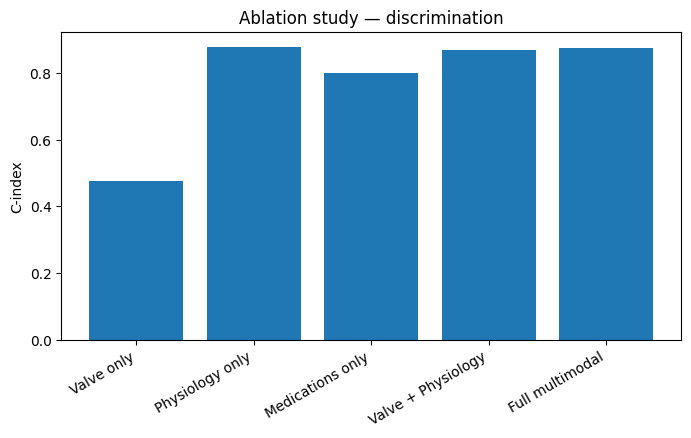

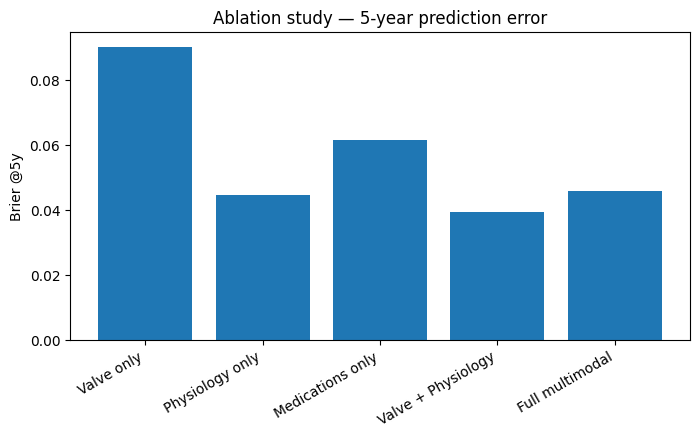

In [11]:
plt.figure(figsize=(8,4))
plt.bar(results_df["model"], results_df["c_index"])
plt.ylabel("C-index")
plt.title("Ablation study — discrimination")
plt.xticks(rotation=30, ha="right")
plt.show()

plt.figure(figsize=(8,4))
plt.bar(results_df["model"], results_df["brier_5y"])
plt.ylabel("Brier @5y")
plt.title("Ablation study — 5-year prediction error")
plt.xticks(rotation=30, ha="right")
plt.show()


## 10. Save ablation results

In [12]:
OUTDIR = Path("ablation_outputs_v1")
OUTDIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    OUTDIR / "ablation_metrics.csv",
    index=False,
)

for name, h in histories.items():
    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    pd.DataFrame(h).to_csv(
        OUTDIR / f"history_{safe_name}.csv",
        index=False,
    )

print("Saved to:", OUTDIR.resolve())


Saved to: C:\Users\User\OneDrive\Υπολογιστής\πανεπιστημιο\workstation\docathon\ablation_outputs_v1


# How to interpret this notebook

Do **not** focus only on which model has the highest number.

Ask:

- Does physiology carry most of the signal?
- Do static valve features add information beyond physiology?
- Do medications improve discrimination or calibration?
- Does the full model consistently improve C-index, Brier score and IBS?

If the full model barely improves over physiology-only, that means the physiology branch is doing most of the predictive work.

That is scientifically useful information and helps decide whether a more complex multimodal architecture is justified.
